# WESAD Dataset: BiLSTM for Binary Stress Detection

This notebook demonstrates the process of building and evaluating a Bidirectional Long Short-Term Memory (BiLSTM) model for stress detection using the WESAD (Wearable Stress and Affect Detection) dataset. The pipeline includes:

1.  **Data Loading and Preprocessing**: Loading physiological sensor data and converting multi-class labels into binary stress/no-stress labels.
2.  **Feature Engineering**: Adding derived features to capture complex relationships within the data.
3.  **Per-Subject Normalization**: Normalizing features independently for each subject to account for individual differences.
4.  **Subject Splits**: Dividing the dataset into training, validation, and test sets based on subjects to ensure no data leakage.
5.  **Sequence Creation**: Transforming time-series data into sequences suitable for recurrent neural networks, with labels determined by majority vote within each sequence.
6.  **BiLSTM Model Definition**: Designing a BiLSTM architecture with BatchNorm, Dropout, and a fully connected output layer.
7.  **Training and Evaluation**: Training the model with class weighting and label smoothing, implementing early stopping, and evaluating performance on the test set using classification reports and confusion matrices.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
full_df_drive = pd.read_pickle("/content/drive/MyDrive/wesad_full_preprocessed.pkl")

In [ ]:
full_df = full_df_drive

In [ ]:
full_df

,bpm,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,label,scr_peak_freq,scr_amp_mean,scl_mean,scl_slope,lf_power,HRV_MeanNN_bvp,HRV_SDNN_bvp,HRV_RMSSD_bvp,temp_mean,temp_std,subject
0,71.600077,837.987928,64.162813,50.240556,1,61.0,0.003176,2.190200,-5.555445e-06,8.728580e-07,863.511029,307.907430,444.194808,35.828750,0.054123,S2
1,71.620713,837.746479,48.339731,45.156809,1,94.5,0.002594,1.975037,-4.674417e-06,2.750015e-07,837.765957,172.185794,246.604310,35.790833,0.032573,S2
2,72.004891,833.276723,54.334890,51.117295,1,97.5,0.002551,1.802472,-3.522025e-06,5.179775e-07,829.545455,143.060255,199.981603,35.850833,0.057163,S2
3,72.173560,831.329365,55.154117,50.347728,1,60.0,0.003149,1.673080,-2.591458e-06,4.824999e-07,837.698063,152.479423,209.321405,35.907167,0.017377,S2
4,72.042895,832.837163,53.472406,50.318617,1,47.5,0.003630,1.571895,-2.159915e-06,2.903708e-07,800.253378,176.838133,223.154754,35.903917,0.020178,S2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,59.997119,1000.048019,154.141818,120.983374,4,31.5,0.005707,7.138802,-2.660445e-07,2.895767e-05,977.143595,303.242040,370.562943,32.293792,0.024010,S17
681,59.304852,1011.721612,168.770916,132.703312,4,42.0,0.005034,7.127027,-2.106074e-07,2.898417e-05,972.720287,289.400395,350.708473,32.287000,0.030594,S17
682,58.328445,1028.657635,165.987811,143.569095,4,48.0,0.004389,7.097907,-1.154113e-06,2.106408e-05,978.693182,253.178042,278.019643,32.321583,0.036606,S17
683,58.710379,1021.965812,146.216863,142.923384,4,41.5,0.004083,7.046501,-1.024168e-06,2.648288e-05,996.454832,210.089190,266.484309,32.320667,0.032242,S17


In [ ]:
# transform the 4 labels into binary labels: 0 for no stress and 1 for stress
curr_labels = full_df['label']
bin_labels = []
for label in curr_labels:
  if (label == 1 or label == 4 or label == 3):
    bin_labels.append(0)

  else:
    bin_labels.append(1)

# baseline, medetation, amusement ===> no stress (0)
# stress  ===========================> stress (1)

In [ ]:
pd.Series(bin_labels).value_counts()

,count
0,518
1,167


In [ ]:
full_df['label'] = bin_labels

In [ ]:
# ═══════════════════════════════════════════════════════════
# OPTIMIZATION CELL — Replace cells 21 onwards with this
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. ADD DERIVED FEATURES before normalization ─────────────────
# These capture cross-modal relationships the model can't learn with raw features

def add_derived_features(df):
    df = df.copy()
    # Autonomic balance: ratio of sympathetic (EDA) to parasympathetic (HRV)
    df['eda_hrv_ratio']   = df['scl_mean'] / (df['HRV_RMSSD'] + 1e-8)
    # Cardiac efficiency
    df['bpm_hrv_ratio']   = df['bpm'] / (df['HRV_SDNN'] + 1e-8)
    # Wrist vs chest HRV agreement (disagreement = artifact or stress)
    df['hrv_chest_wrist'] = df['HRV_RMSSD'] - df['HRV_RMSSD_bvp']
    # SCL normalized by SCR activity
    df['scl_scr_ratio']   = df['scl_mean'] / (df['scr_peak_freq'] + 1e-8)
    return df

full_df_feat = add_derived_features(full_df)

FEATURE_COLS = [
    'bpm', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD',
    'scr_peak_freq', 'scr_amp_mean', 'scl_mean',
    'scl_slope', 'lf_power',
    'HRV_MeanNN_bvp', 'HRV_SDNN_bvp', 'HRV_RMSSD_bvp',
    'temp_mean', 'temp_std',
    'eda_hrv_ratio', 'bpm_hrv_ratio', 'hrv_chest_wrist', 'scl_scr_ratio'
]
INPUT_SIZE = len(FEATURE_COLS)  # now 18

# ── 2. Per-subject normalization ──────────────────────────────────
def normalize_per_subject(df, feature_cols):
    df = df.copy()
    for subj in df['subject'].unique():
        mask = df['subject'] == subj
        scaler = StandardScaler()
        df.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])
    return df

full_df_norm = normalize_per_subject(full_df_feat, FEATURE_COLS)

# ── 3. Subject splits ─────────────────────────────────────────────
TRAIN_SUBJECTS = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11']
VAL_SUBJECTS   = ['S13','S14']
TEST_SUBJECTS  = ['S15','S16','S17']

train_df = full_df_norm[full_df_norm['subject'].isin(TRAIN_SUBJECTS)].reset_index(drop=True)
val_df   = full_df_norm[full_df_norm['subject'].isin(VAL_SUBJECTS)].reset_index(drop=True)
test_df  = full_df_norm[full_df_norm['subject'].isin(TEST_SUBJECTS)].reset_index(drop=True)

# ── 4. Sequence creation with majority vote label ─────────────────
SEQ_LEN = 5

def create_sequences(df, feature_cols, seq_len):
    X_all, y_all = [], []
    for subj in df['subject'].unique():
        sdf = df[df['subject'] == subj].reset_index(drop=True)
        X   = sdf[feature_cols].values.astype(np.float32)
        y   = sdf['label'].values.astype(int)
        if len(X) < seq_len:
            continue
        for i in range(len(X) - seq_len + 1):
            X_all.append(X[i:i+seq_len])
            y_all.append(int(np.bincount(y[i:i+seq_len]).argmax()))  # majority vote
    return np.array(X_all), np.array(y_all)

X_train_seq, y_train_seq = create_sequences(train_df, FEATURE_COLS, SEQ_LEN)
X_val_seq,   y_val_seq   = create_sequences(val_df,   FEATURE_COLS, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(test_df,  FEATURE_COLS, SEQ_LEN)

# 0-index labels
y_train_seq = y_train_seq
y_val_seq   = y_val_seq
y_test_seq  = y_test_seq

print(f"X_train: {X_train_seq.shape} | X_val: {X_val_seq.shape} | X_test: {X_test_seq.shape}")
print(f"Train labels: {dict(zip(*np.unique(y_train_seq, return_counts=True)))}")
print(f"Val labels:   {dict(zip(*np.unique(y_val_seq,   return_counts=True)))}")
print(f"Test labels:  {dict(zip(*np.unique(y_test_seq,  return_counts=True)))}")

X_train: (413, 5, 18) | X_val: (85, 5, 18) | X_test: (127, 5, 18)
Train labels: {np.int64(0): np.int64(303), np.int64(1): np.int64(110)}
Val labels:   {np.int64(0): np.int64(63), np.int64(1): np.int64(22)}
Test labels:  {np.int64(0): np.int64(92), np.int64(1): np.int64(35)}


In [ ]:
X_train_seq

array([[[ 0.05901197, -0.12560384, -0.27082327, ...,  0.10049258,
         -0.36225355, -0.38883013],
        [ 0.06343341, -0.13010713, -1.3351275 , ...,  1.6907879 ,
          0.32183543, -0.49957377],
        [ 0.14574698, -0.2134732 , -0.9318765 , ...,  1.010633  ,
          0.50869423, -0.51738244],
        [ 0.18188572, -0.24979368, -0.876773  , ...,  0.93833375,
          0.47276974, -0.44802293],
        [ 0.1538895 , -0.22167152, -0.98988956, ...,  1.1066754 ,
          0.42350832, -0.40958688]],

       [[ 0.06343341, -0.13010713, -1.3351275 , ...,  1.6907879 ,
          0.32183543, -0.49957377],
        [ 0.14574698, -0.2134732 , -0.9318765 , ...,  1.010633  ,
          0.50869423, -0.51738244],
        [ 0.18188572, -0.24979368, -0.876773  , ...,  0.93833375,
          0.47276974, -0.44802293],
        [ 0.1538895 , -0.22167152, -0.98988956, ...,  1.1066754 ,
          0.42350832, -0.40958688],
        [-0.08478247,  0.02228096, -0.7449515 , ...,  0.648305  ,
          0.31

In [ ]:
# ── 5. DataLoaders ────────────────────────────────────────────────
def make_loader(X, y, batch_size=32, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_seq, y_train_seq, batch_size=32, shuffle=True)
val_loader   = make_loader(X_val_seq,   y_val_seq,   batch_size=32, shuffle=False)
test_loader  = make_loader(X_test_seq,  y_test_seq,  batch_size=32, shuffle=False)

In [ ]:
# ── 6. Improved BiLSTM  ────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.bn   = nn.BatchNorm1d(hidden_size * 2)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = out[:, -1, :]        # last timestep
        out    = self.bn(out)
        out    = self.drop(out)
        return self.fc(out)

# Compute balanced class weights
counts        = np.bincount(y_train_seq)
class_weights = torch.tensor(1.0 / counts, dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * len(counts)).to(device)
print(f"Class weights: {class_weights}")
print(f"Input size: {INPUT_SIZE}")

HIDDEN_SIZE = 128
NUM_LAYERS  = 2
NUM_CLASSES = 2
DROPOUT     = 0.3
LR          = 0.001
NUM_EPOCHS  = 80
PATIENCE    = 15

model     = BiLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Class weights: tensor([0.5327, 1.4673])
Input size: 18
Trainable parameters: 563,906


In [ ]:
# ── 7. Training with label smoothing + best model saving ──────────
train_losses, val_losses     = [], []
train_accs,   val_accs       = [], []
best_val_acc     = 0.0
best_model_state = None
patience_counter = 0

# Label smoothing reduces overconfidence — helps generalization
smooth_criterion = nn.CrossEntropyLoss(
    weight=class_weights, label_smoothing=0.1
)

# Also use CrossEntropyLoss for validation to match the training loss and model output
# Apply class weights for consistency with training, or remove if not desired for validation
val_criterion = nn.CrossEntropyLoss(weight=class_weights)

for epoch in range(NUM_EPOCHS):
    # ── Train ──
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = smooth_criterion(out, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    avg_train_loss = epoch_loss / len(train_loader)
    avg_train_acc  = correct / total
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out       = model(X_batch)
            val_loss += val_criterion(out, y_batch).item() # Use val_criterion here
            val_correct += (out.argmax(1) == y_batch).sum().item()
            val_total   += len(y_batch)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)
    scheduler.step() # This must be inside the loop

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.3f} | "
          f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.3f}")

    # Save best by val accuracy, not val loss
    if avg_val_acc > best_val_acc:
        best_val_acc     = avg_val_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f"  ✓ New best val acc: {best_val_acc:.3f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)
print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 01 | Train Loss: 0.4529 Acc: 0.828 | Val Loss: 0.6244 Acc: 0.588
  ✓ New best val acc: 0.588
Epoch 02 | Train Loss: 0.3445 Acc: 0.944 | Val Loss: 0.5136 Acc: 0.882
  ✓ New best val acc: 0.882
Epoch 03 | Train Loss: 0.3180 Acc: 0.966 | Val Loss: 0.3764 Acc: 0.918
  ✓ New best val acc: 0.918
Epoch 04 | Train Loss: 0.3240 Acc: 0.954 | Val Loss: 0.3140 Acc: 0.941
  ✓ New best val acc: 0.941
Epoch 05 | Train Loss: 0.3071 Acc: 0.978 | Val Loss: 0.2591 Acc: 0.965
  ✓ New best val acc: 0.965
Epoch 06 | Train Loss: 0.2964 Acc: 0.983 | Val Loss: 0.2552 Acc: 0.941
Epoch 07 | Train Loss: 0.2971 Acc: 0.985 | Val Loss: 0.2009 Acc: 0.953
Epoch 08 | Train Loss: 0.3115 Acc: 0.983 | Val Loss: 0.1980 Acc: 0.953
Epoch 09 | Train Loss: 0.2928 Acc: 0.978 | Val Loss: 0.2691 Acc: 0.941
Epoch 10 | Train Loss: 0.3006 Acc: 0.981 | Val Loss: 0.1911 Acc: 0.953
Epoch 11 | Train Loss: 0.3057 Acc: 0.978 | Val Loss: 0.2015 Acc: 0.965
Epoch 12 | Train Loss: 0.2956 Acc: 0.985 | Val Loss: 0.1871 Acc: 0.965
Epoch 13

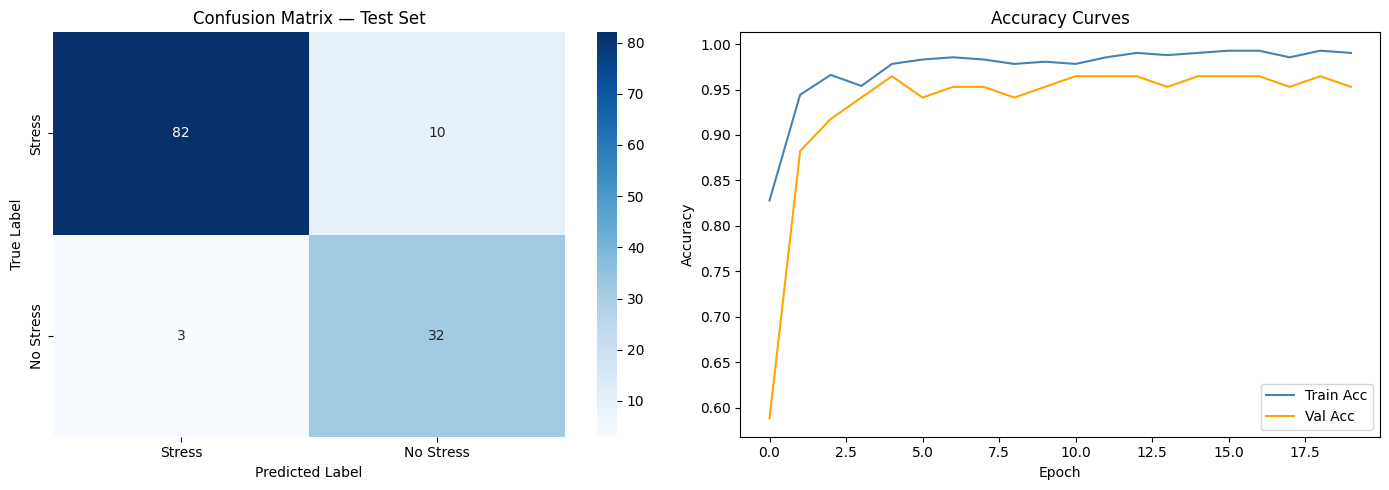

              precision    recall  f1-score   support

      Stress       0.96      0.89      0.93        92
   No Stress       0.76      0.91      0.83        35

    accuracy                           0.90       127
   macro avg       0.86      0.90      0.88       127
weighted avg       0.91      0.90      0.90       127



In [ ]:
# ── 8. Evaluation ────────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = ['Stress', 'No Stress']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix — Test Set')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Loss + accuracy curves
axes[1].plot(train_accs, label='Train Acc', color='steelblue')
axes[1].plot(val_accs,   label='Val Acc',   color='orange')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds,
                             target_names=class_names, zero_division=0))

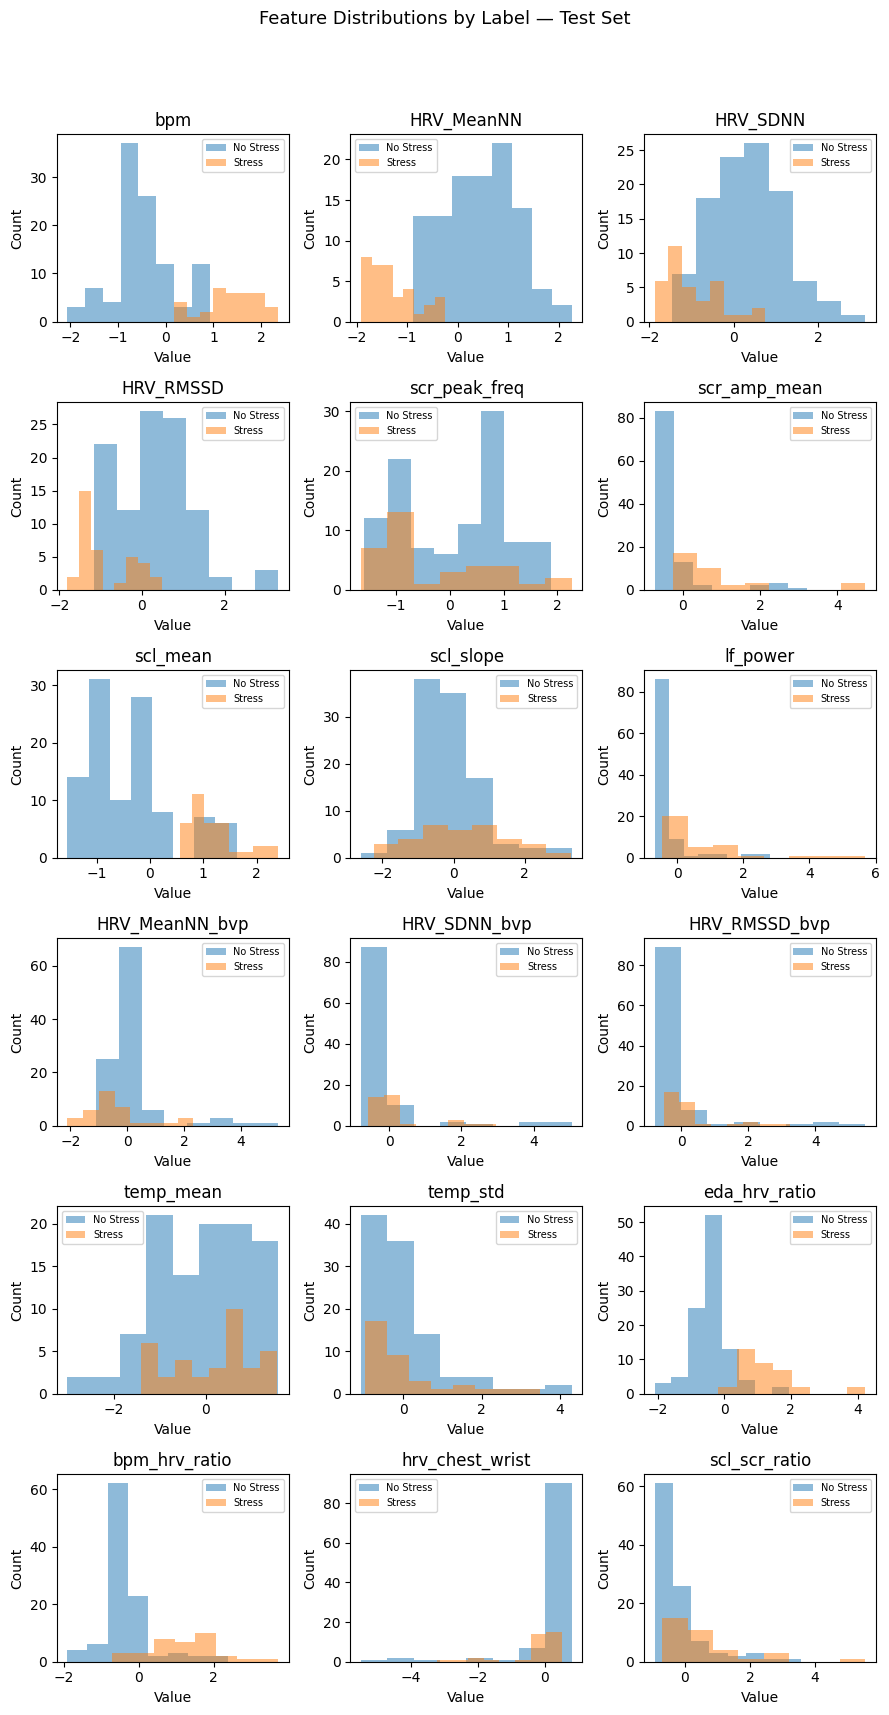

In [ ]:
label_map = {0: 'No Stress', 1: 'Stress'}
plot_df   = test_df[test_df['label'].isin([0,1])].copy() # Original labels are 1-indexed
plot_df['label_name'] = plot_df['label'].map(label_map)

features_to_plot = ['bpm', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD',
    'scr_peak_freq', 'scr_amp_mean', 'scl_mean',
    'scl_slope', 'lf_power',
    'HRV_MeanNN_bvp', 'HRV_SDNN_bvp', 'HRV_RMSSD_bvp',
    'temp_mean', 'temp_std',
    'eda_hrv_ratio', 'bpm_hrv_ratio', 'hrv_chest_wrist', 'scl_scr_ratio']

# Calculate rows and columns needed for the plots
num_features = len(features_to_plot)
num_cols = 3  # Let's keep 6 columns per row
num_rows = (num_features + num_cols - 1) // num_cols # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    for label_name, grp in plot_df.groupby('label_name'):
        axes[i].hist(grp[feat], bins=8, alpha=0.5, label=label_name)
    axes[i].set_title(feat)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Feature Distributions by Label — Test Set', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle
plt.show()

In [ ]:
def check_accuracy(loader, model, is_train_loader=True):
    if is_train_loader:
        print("Checking accuracy on the training data")
    else:
        print("Checking accuracy on the test data")

    num_correct = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            # Removed .unsqueeze(1) as input is already 3D (batch_size, seq_len, input_size)
            x = x.to(device=device)
            y = y.to(device=device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

        print(
            f"Correct examples / total examples = {num_correct} / {num_samples} with accuracy "
            f"{float(num_correct)/float(num_samples)*100:.2f}"
        )

    model.train()

check_accuracy(train_loader, model, is_train_loader=True)
check_accuracy(test_loader, model, is_train_loader=False)

Checking accuracy on the training data
Correct examples / total examples = 405 / 413 with accuracy 98.06
Checking accuracy on the test data
Correct examples / total examples = 114 / 127 with accuracy 89.76


In [ ]:
# Make sure test subjects never appeared in training
print("Train subjects:", TRAIN_SUBJECTS)
print("Test subjects: ", TEST_SUBJECTS)
assert len(set(TRAIN_SUBJECTS) & set(TEST_SUBJECTS)) == 0
print("No leakage confirmed")

Train subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11']
Test subjects:  ['S15', 'S16', 'S17']
No leakage confirmed


In [ ]:
import pickle

# Save everything needed to reproduce predictions
artifacts = {
    'feature_cols' : FEATURE_COLS,
    'input_size'   : INPUT_SIZE,
    'hidden_size'  : HIDDEN_SIZE,
    'num_layers'   : NUM_LAYERS,
    'num_classes'  : NUM_CLASSES,
    'dropout'      : DROPOUT,
    'seq_len'      : SEQ_LEN,
    'train_subjects': TRAIN_SUBJECTS,
    'test_subjects' : TEST_SUBJECTS,
}

with open('/content/drive/MyDrive/wesad_model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Artifacts saved")

Artifacts saved


In [ ]:
import torch

# Save model weights
torch.save(model.state_dict(), 'bilstm_wesad_binary.pth')

# If using Google Colab, also save to Drive
torch.save(model.state_dict(), '/content/drive/MyDrive/bilstm_wesad_binary.pth')

print("Model saved successfully")

Model saved successfully


In [ ]:
# for inference
# Recreate the model architecture first
model = BiLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)

# Then load the weights
model.load_state_dict(torch.load('bilstm_wesad_binary.pth', map_location=device))
model.eval()

print("Model loaded successfully")

Model loaded successfully
